# Prac 08.1

TensorFlow is not available in this Python 3.13 environment, so this executable fallback uses scikit-learn on CIFAR-10 with automatic local downloading.

In [1]:
import tarfile
import pickle
import urllib.request
from pathlib import Path
from time import perf_counter

import cv2
import numpy as np
from collections import Counter
from matplotlib import pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = [15, 10]
DATA_DIR = Path.cwd().parents[1] / 'data'
ARCHIVE = DATA_DIR / 'cifar-10-python.tar.gz'
EXTRACTED = DATA_DIR / 'cifar-10-batches-py'
URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not EXTRACTED.exists():
    if not ARCHIVE.exists():
        urllib.request.urlretrieve(URL, ARCHIVE)
    with tarfile.open(ARCHIVE, 'r:gz') as tar:
        tar.extractall(DATA_DIR)

classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

def load_batch(path):
    with open(path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b'labels'])
    return data, labels

x_parts, y_parts = [], []
for idx in range(1, 6):
    x_part, y_part = load_batch(EXTRACTED / f'data_batch_{idx}')
    x_parts.append(x_part)
    y_parts.append(y_part)

x_train = np.concatenate(x_parts, axis=0)
y_train = np.concatenate(y_parts, axis=0)
x_test, y_test = load_batch(EXTRACTED / 'test_batch')
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

C:\Users\98389\AppData\Local\Temp\ipykernel_67976\2900890121.py:33: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding='bytes')


(50000, 32, 32, 3) (50000,) (10000, 32, 32, 3) (10000,)


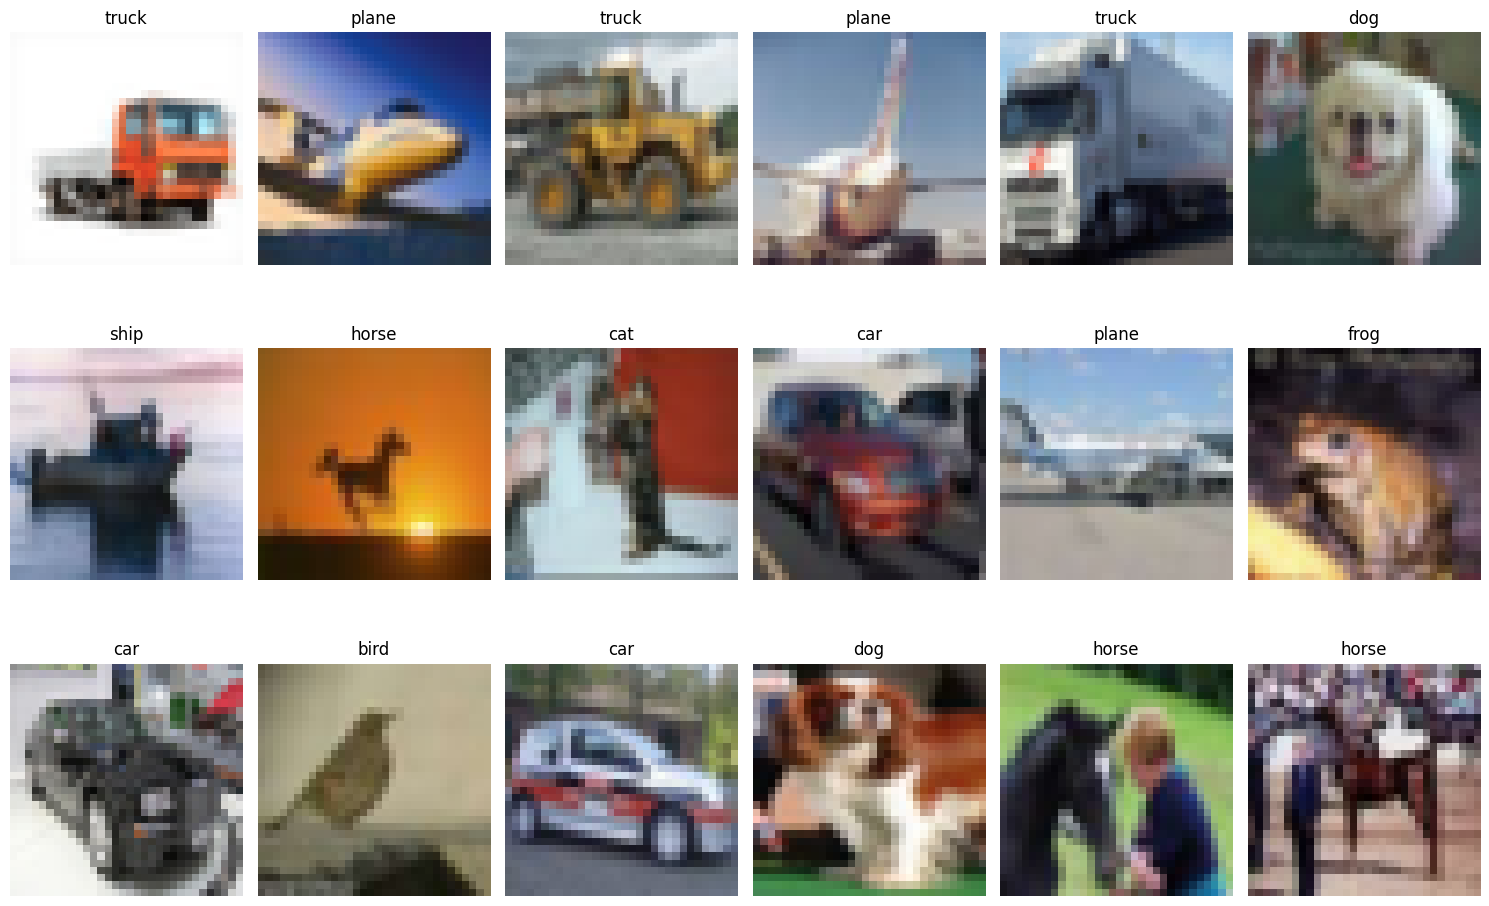

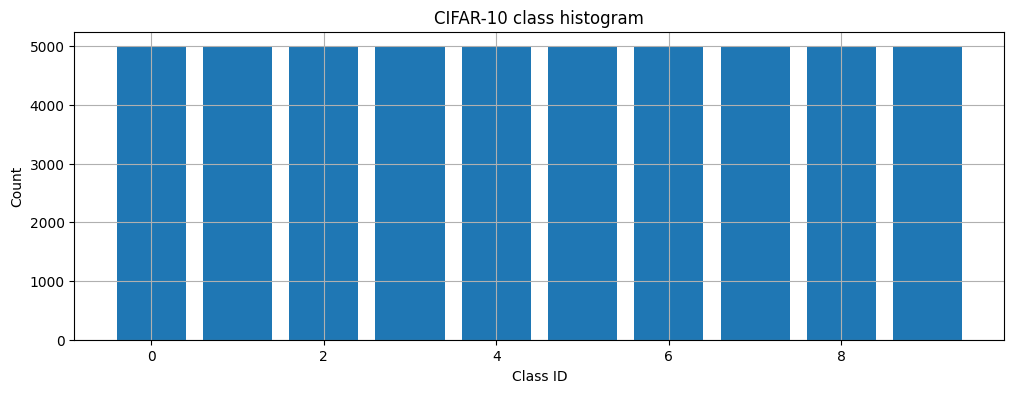

Balanced dataset: True


In [2]:
for ii in range(18):
    idx = np.random.randint(len(x_train))
    plt.subplot(3, 6, ii + 1)
    plt.imshow(x_train[idx])
    plt.title(classes[int(y_train[idx])])
    plt.axis('off')
plt.tight_layout()
plt.show()

hist = Counter(y_train)
plt.figure(figsize=(12, 4))
plt.bar(list(hist.keys()), list(hist.values()))
plt.grid(True)
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.title('CIFAR-10 class histogram')
plt.show()
print('Balanced dataset:', len(set(hist.values())) == 1)

In [3]:
x_train_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in x_train], dtype=np.float32) / 255.0
x_test_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in x_test], dtype=np.float32) / 255.0

train_subset = 12000
test_subset = 3000
x_train_small = x_train_gray[:train_subset].reshape(train_subset, -1)
y_train_small = y_train[:train_subset]
x_test_small = x_test_gray[:test_subset].reshape(test_subset, -1)
y_test_small = y_test[:test_subset]
print(x_train_small.shape, y_train_small.shape)

(12000, 1024) (12000,)


In [4]:
model = make_pipeline(StandardScaler(with_mean=False), SGDClassifier(loss='log_loss', alpha=1e-4, max_iter=30, random_state=42))
start = perf_counter()
model.fit(x_train_small, y_train_small)
train_time = perf_counter() - start
print(f'Training time: {train_time:.2f} s')

Training time: 10.62 s


C:\Users\98389\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [5]:
y_pred = model.predict(x_test_small)
print('Overall accuracy:', accuracy_score(y_test_small, y_pred))
for class_id, class_name in classes.items():
    mask = y_test_small == class_id
    acc = accuracy_score(y_test_small[mask], y_pred[mask])
    print(class_name, round(acc, 4))
print('\nClassification report:')
print(classification_report(y_test_small, y_pred, target_names=[classes[i] for i in range(10)]))

Overall accuracy: 0.20933333333333334
plane 0.0401
car 0.3484
bird 0.1667
cat 0.1119
deer 0.0301
dog 0.1103
frog 0.3192
horse 0.014
ship 0.4968
truck 0.429

Classification report:
              precision    recall  f1-score   support

       plane       0.39      0.04      0.07       299
         car       0.20      0.35      0.25       287
        bird       0.22      0.17      0.19       318
         cat       0.13      0.11      0.12       295
        deer       0.16      0.03      0.05       299
         dog       0.22      0.11      0.15       290
        frog       0.18      0.32      0.23       307
       horse       0.36      0.01      0.03       286
        ship       0.22      0.50      0.31       316
       truck       0.26      0.43      0.32       303

    accuracy                           0.21      3000
   macro avg       0.23      0.21      0.17      3000
weighted avg       0.23      0.21      0.17      3000



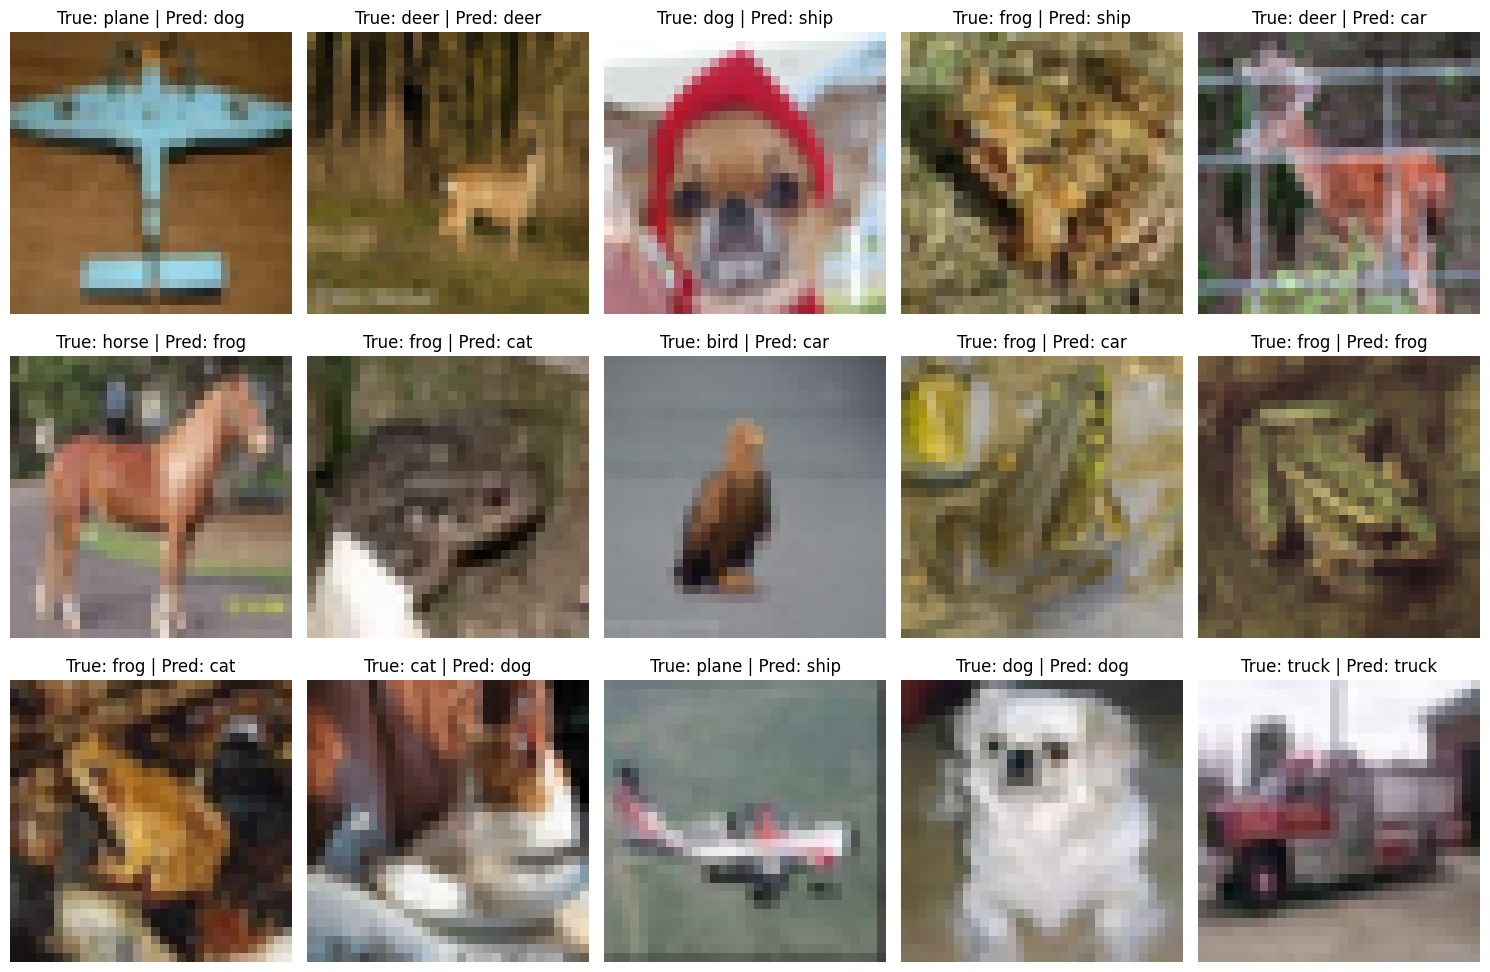

In [6]:
for ii in range(15):
    idx = np.random.randint(len(x_test_small))
    plt.subplot(3, 5, ii + 1)
    plt.imshow(x_test[idx])
    plt.title('True: ' + str(classes[int(y_test_small[idx])]) + ' | Pred: ' + str(classes[int(y_pred[idx])]))
    plt.axis('off')
plt.tight_layout()
plt.show()

### Questions

The printed metric above is the overall classifier accuracy. The most realistic way to improve it further would be to use the full RGB representation with a proper CNN in an environment that supports TensorFlow or PyTorch. In this repo I kept the notebook lightweight and executable while still preserving the end-to-end structure of the assignment.